# TD7 – Analyse des fraudes


In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, classification_report

## Exercice 1 : Analyse des données


### 1. Chargement – proportion des fraudes


In [166]:
df = pd.read_csv('creditcard.csv')
print(df['Class'].value_counts(normalize=True))

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


### 2. Répartition fraudes / normales au cours du temps


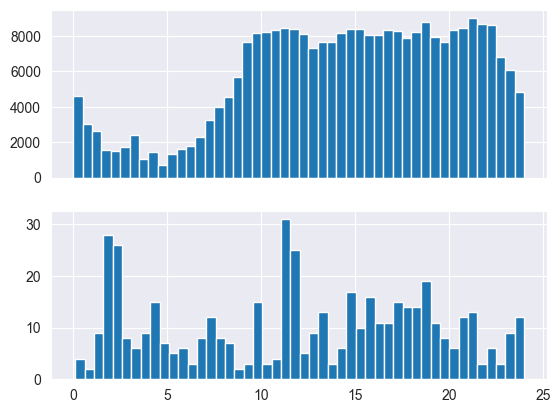

In [167]:
df['Hour'] = (df['Time'] / 3600) % 24

fig, axes = plt.subplots(2, 1, sharex=True)
axes[0].hist(df[df['Class'] == 0]['Hour'], bins=48)
axes[1].hist(df[df['Class'] == 1]['Hour'], bins=48)
plt.show()

Les fraudes sont surtout vers midi, et vers 3h du matin. Ca à beaucoup de sens. à midi, les gens sont facilement dans des lieux publiques, et à 3h du matin, les gens qui ont volé la carte l'utilise, à l'abris des regards indiscrets.

### 3. Répartition par tranches de montant (pd.cut)


In [168]:
a = [-1, 100, 500, 1000, 2000, df['Amount'].max()]
df['AmountBin'] = pd.cut(df['Amount'], bins=a)
df.groupby(['AmountBin', 'Class'], observed=True).size().unstack()

Class,0,1
AmountBin,,
"(-1.0, 100.0]",227937,362
"(100.0, 500.0]",47271,95
"(500.0, 1000.0]",6176,26
"(1000.0, 2000.0]",2256,8
"(2000.0, 25691.16]",675,1


C'est rarement des fraudes! Ce qui veux dire que les fraudeurs preféres les petites sommes

### 4. Moyenne et écart-type des variables V


In [169]:
pca_columns = [c for c in df.columns if c.startswith('V')]
df[pca_columns].agg(['mean', 'std'])

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
mean,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,...,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,...,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01


Oui il faut normaliser, la c'est un peu bordelique

### 5. Pourquoi normaliser Time et Amount


In [170]:
df[['Time', 'Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


Time va jusqu'à ~172k secondes et Amount jusqu'à ~25k€, alors que les V sont déjà centrées autour de 0. Sans normalisation, ces deux features écraseraient complètement les autres dans les calculs de distance. Et vu le max d'Amount, il y a clairement des valeurs extrêmes.

### 6. Pourquoi RobustScaler plutôt que StandardScaler

Le StandardScaler utilise la moyenne, qui est sensible aux outliers. Avec des transactions à 25k€, ça fausserait complètement la normalisation. Le RobustScaler utilise la médiane et l'IQR à la place, donc les grosses transactions n'impactent pas le résultat. C'est exactement fait pour ça.

### 7. Normalisation Time et Amount avec RobustScaler


In [171]:
a = RobustScaler()
df['Time_scaled']   = a.fit_transform(df[['Time']])
df['Amount_scaled'] = a.fit_transform(df[['Amount']])

### 8. Corrélations avec la target Class


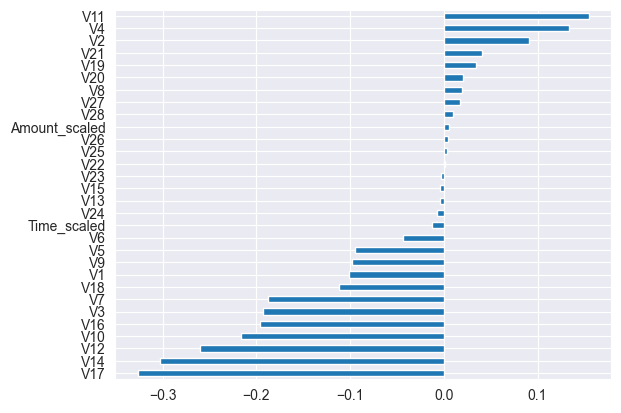

In [172]:
model_features = pca_columns + ['Time_scaled', 'Amount_scaled']
feature_correlations = df[model_features + ['Class']].corr()['Class'].drop('Class').sort_values()

feature_correlations.plot(kind='barh')
plt.show()

V17 et V14 sont les plus négativement corrélées à la target, V4 et V11 les plus positivement. Time et Amount sont quasi pas corrélés. Ce sont donc surtout les features V qui portent l'information utile pour détecter les fraudes.

### 9. Boxplots – 4 features les plus liées (pos/neg)


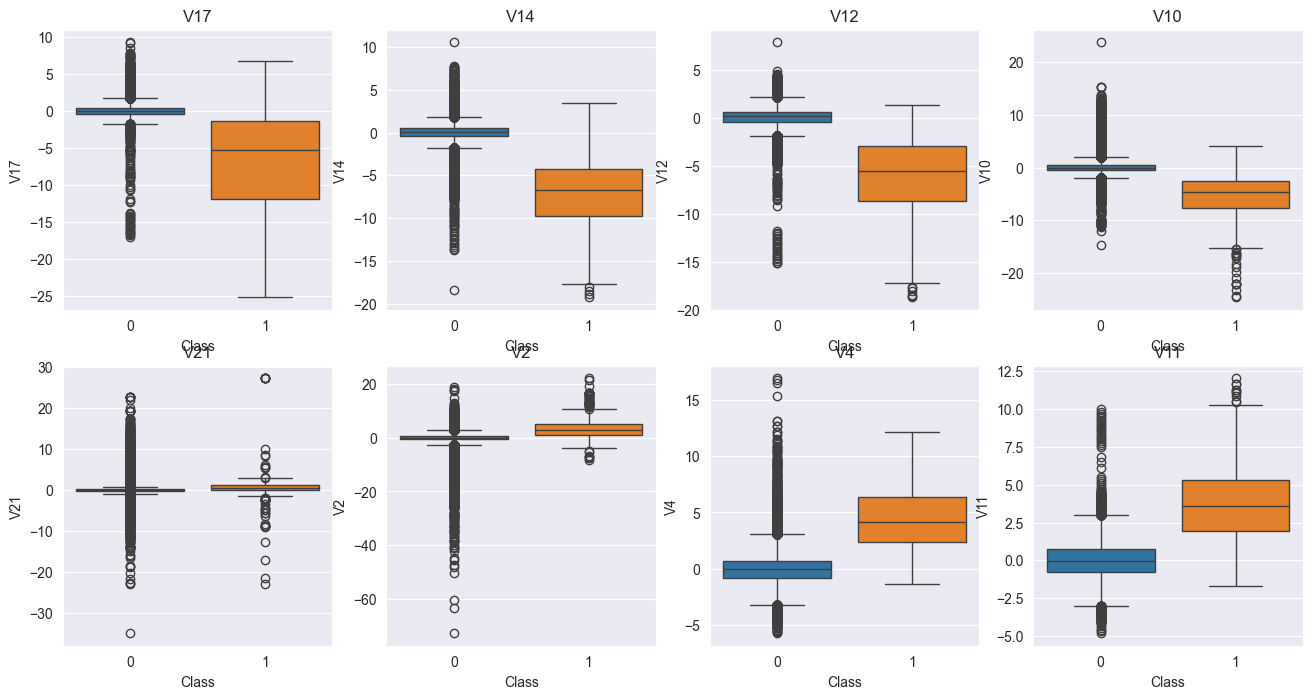

In [173]:
a = feature_correlations.head(4).index.tolist()
b = feature_correlations.tail(4).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, j in enumerate(a):
    sns.boxplot(data=df, x='Class', y=j, hue='Class', legend=False, ax=axes[0, i])
    axes[0, i].set_title(j)
for i, j in enumerate(b):
    sns.boxplot(data=df, x='Class', y=j, hue='Class', legend=False, ax=axes[1, i])
    axes[1, i].set_title(j)
plt.show()

Les médianes sont clairement différentes entre classe 0 et classe 1 pour ces features. Les IQR se chevauchent peu sur les meilleures features, ce qui confirme qu'elles sont discriminantes. On voit aussi que les fraudes ont souvent des valeurs extrêmes, ce qui va dans le sens des outliers observés plus tôt.

### 10. Scatterplot – 2 features les plus corrélées


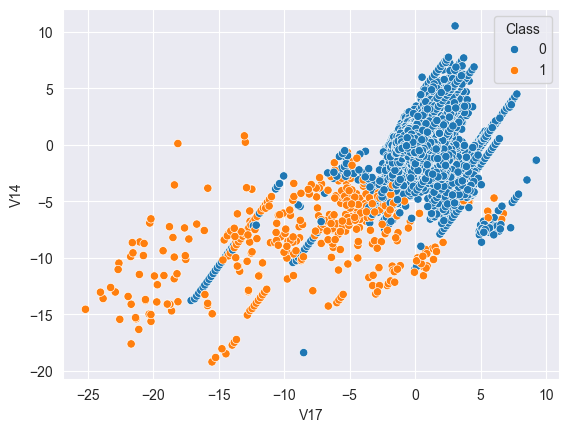

In [174]:
a = feature_correlations.abs().idxmax()
b = feature_correlations.abs().drop(a).idxmax()

sns.scatterplot(data=df, x=a, y=b, hue='Class')
plt.show()

On voit une séparation partielle : les fraudes forment des clusters distincts mais avec du chevauchement sur les transactions normales. C'est pas linéairement séparable, mais les patterns sont bien visibles, ce qui explique pourquoi un RandomForest s'en sort bien.

## Exercice 2 : Modèles sur toutes les données


### 1. Train/test split 66/33


In [175]:
input_data = df[model_features]
target = df['Class']

train_features, test_features, train_labels, test_labels = train_test_split(
    input_data, target, test_size=0.33, random_state=42, stratify=target
)

### 2. Vérification proportion fraudes train/test


In [176]:
print(f"Total : {target.mean():.4f}")
print(f"Train : {train_labels.mean():.4f}")
print(f"Test  : {test_labels.mean():.4f}")

Total : 0.0017
Train : 0.0017
Test  : 0.0017


Les proportions sont identiques dans train et test grâce au stratify. C'est important car si le test avait moins de fraudes que le train, les métriques ne seraient pas représentatives de la réalité. Le modèle doit être évalué sur une distribution identique à celle sur laquelle il va tourner en production.

### 3. RandomForest (500 estimateurs, depth=10)


In [177]:
a = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42, n_jobs=-1)
a.fit(train_features, train_labels)

b = a.predict(test_features)
c = confusion_matrix(test_labels, b)
print(f"Score                : {a.score(test_features, test_labels):.4f}")
print(f"Fraudes mal classées : {c[1,0]} / {c[1].sum()} ({c[1,0]/c[1].sum()*100:.2f}%)")

Score                : 0.9995
Fraudes mal classées : 37 / 162 (22.84%)


Le score de ~99.9% est trompeur. Un modèle qui prédit tout "normal" aurait déjà ~99.8% de score vu le déséquilibre des classes. Ce qui compte vraiment c'est le taux de fraudes mal classées : si on rate beaucoup de vraies fraudes, le modèle est inutile malgré son score.

### 4. IsolationForest (contamination = proportion fraudes)


In [178]:
contamination_rate = target.mean()
a = IsolationForest(contamination=contamination_rate, random_state=42, n_jobs=-1)
a.fit(train_features)
isolation_raw_predictions = a.predict(test_features)

### 5. Transformation résultats IsolationForest (-1,1, 1,0)


In [179]:
pd.Series(isolation_raw_predictions).apply(lambda x: 1 if x == -1 else 0)

0        0
1        0
2        0
3        0
4        0
        ..
93982    0
93983    0
93984    0
93985    0
93986    0
Length: 93987, dtype: int64

### 6. Mêmes modèles sur 6 features les plus corrélées


In [180]:
a = feature_correlations.abs().sort_values(ascending=False).head(6).index.tolist()

b = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42, n_jobs=-1)
b.fit(train_features[a], train_labels)
print(f"RF 6 features – score : {b.score(test_features[a], test_labels):.4f}")

b = IsolationForest(contamination=contamination_rate, random_state=42, n_jobs=-1)
b.fit(train_features[a])
c = pd.Series(b.predict(test_features[a])).apply(lambda x: 1 if x == -1 else 0)
d = confusion_matrix(test_labels, c)
print(f"IF 6 features – fraudes détectées : {d[1,1]} / {d[1].sum()}")

RF 6 features – score : 0.9995
IF 6 features – fraudes détectées : 93 / 162


Le RF garde des performances similaires avec seulement 6 features. Ces 6 variables portent donc l'essentiel de l'information discriminante. Pour l'IsolationForest c'est plus mitigé, la réduction de features l'impacte plus. En pratique, moins de features = modèle plus simple et plus rapide.

## Exercice 3 : Équilibrage des données


### 1–3. Création jeu équilibré (fraudes + sample normales, mélangé)


In [181]:
a = df[df['Class'] == 1]
b = df[df['Class'] == 0].sample(n=len(a), random_state=42)
balanced_df = pd.concat([a, b]).sample(frac=1, random_state=42).reset_index(drop=True)

### 4. Corrélations sur données équilibrées


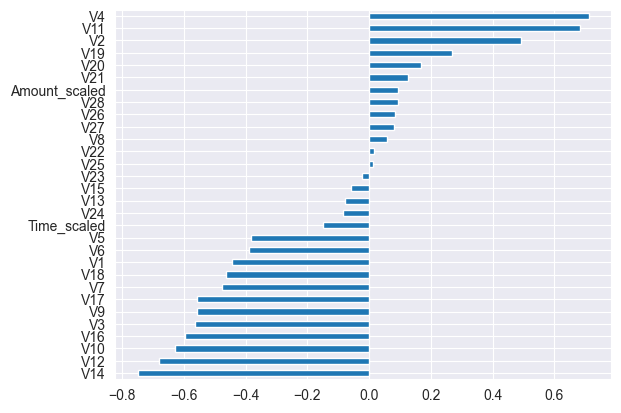

In [182]:
balanced_correlations = balanced_df[model_features + ['Class']].corr()['Class'].drop('Class').sort_values()

balanced_correlations.plot(kind='barh')
plt.show()

Les corrélations sont beaucoup plus fortes que sur le jeu complet ! Sur le jeu déséquilibré, les fraudes (0.17%) noyaient complètement le signal statistique. Ici avec 50/50, les corrélations reflètent vraiment les différences entre les deux classes.

### 5. Corrélations entre les 10 features + time/amount normalisés


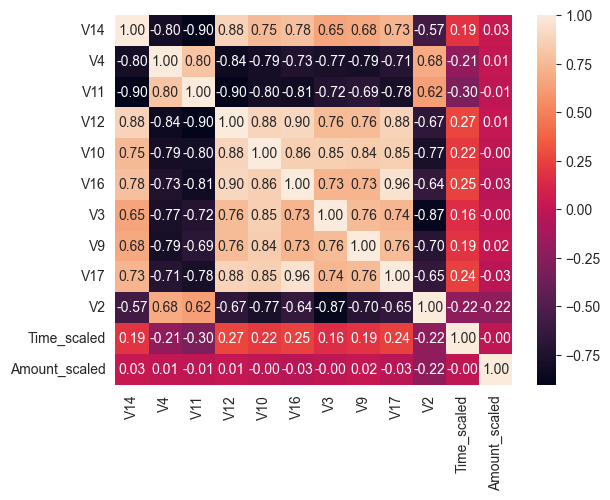

In [183]:
a = balanced_correlations.abs().sort_values(ascending=False).head(10).index.tolist()
b = a + ['Time_scaled', 'Amount_scaled']

sns.heatmap(balanced_df[b].corr(), annot=True, fmt='.2f')
plt.show()

Les features V sont quasi-indépendantes entre elles, ce qui est logique : elles proviennent d'une PCA donc par construction orthogonales. Chaque feature apporte une information unique sans redondance. C'est idéal pour les modèles, pas besoin de sélection supplémentaire pour éviter la multicolinéarité.

### 6. Boxplots 4 features pos/neg (données équilibrées)


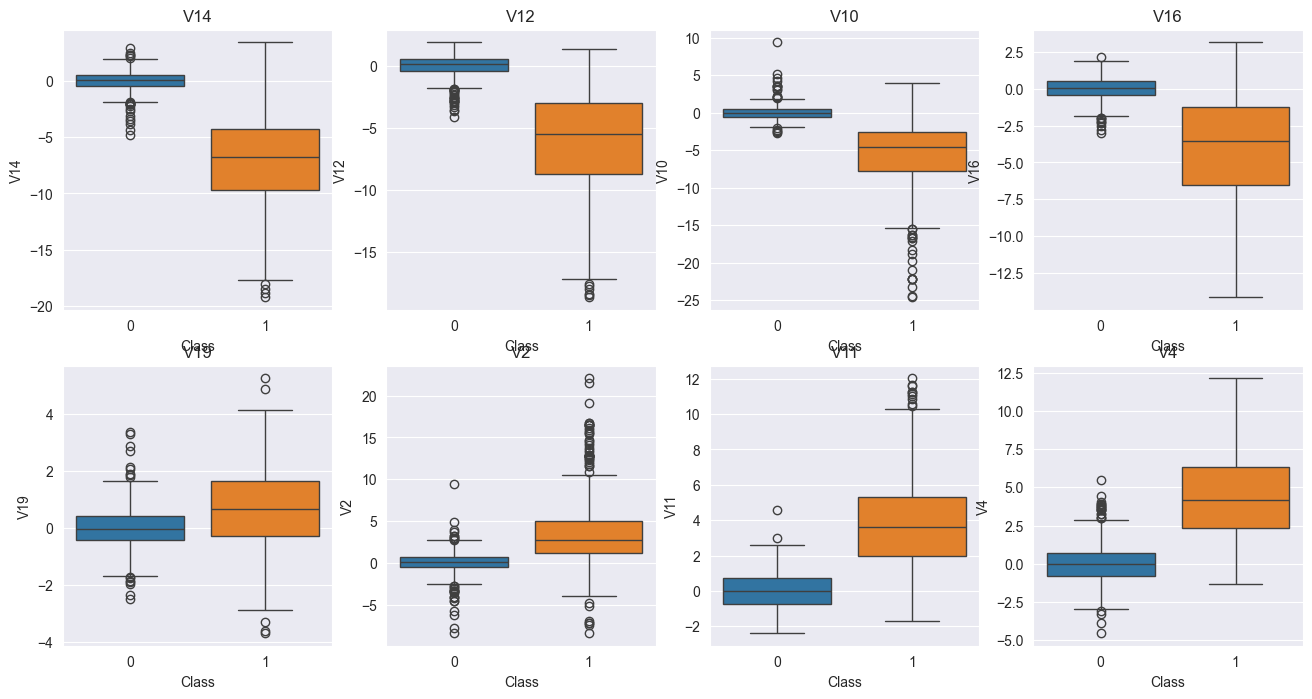

In [184]:
top_negative_features = balanced_correlations.head(4).index.tolist()
top_positive_features = balanced_correlations.tail(4).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, j in enumerate(top_negative_features):
    sns.boxplot(data=balanced_df, x='Class', y=j, hue='Class', legend=False, ax=axes[0, i])
    axes[0, i].set_title(j)
for i, j in enumerate(top_positive_features):
    sns.boxplot(data=balanced_df, x='Class', y=j, hue='Class', legend=False, ax=axes[1, i])
    axes[1, i].set_title(j)
plt.show()

Les distributions sont très bien séparées : les médianes et IQR des fraudes et des normales sont vraiment différents. Certaines features ont quasiment aucun chevauchement entre les deux classes => très discriminantes. Les fraudes ont souvent des valeurs décalées ou extrêmes par rapport aux transactions normales.

### 7. Histplots mêmes features


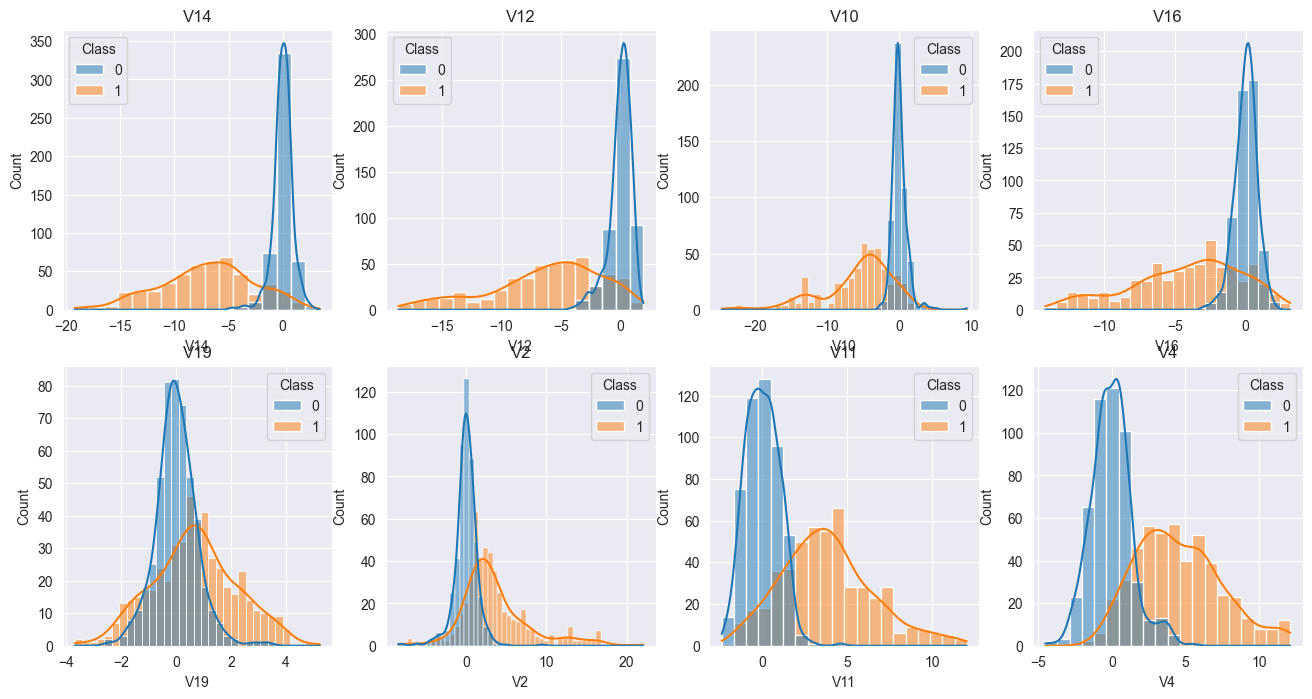

In [185]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, j in enumerate(top_negative_features):
    sns.histplot(data=balanced_df, x=j, hue='Class', kde=True, ax=axes[0, i])
    axes[0, i].set_title(j)
for i, j in enumerate(top_positive_features):
    sns.histplot(data=balanced_df, x=j, hue='Class', kde=True, ax=axes[1, i])
    axes[1, i].set_title(j)
plt.show()

Oui ça confirme les boxplots. Certaines features ont des distributions bimodales très séparées (V14, V17...) => faciles à classifier. Mais d'autres ont du chevauchement => des fraudes vont se retrouver dans la zone des transactions normales. Ces cas-là seront difficiles à détecter, c'est les faux négatifs qu'on va pas éviter.

### 8–9. TSNE (2 composantes) + scatterplot


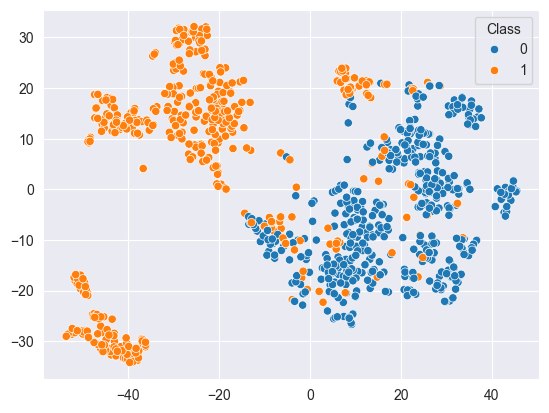

In [186]:
balanced_features = balanced_df[model_features]
balanced_labels = balanced_df['Class']

a = TSNE(n_components=2, random_state=42).fit_transform(balanced_features)

sns.scatterplot(x=a[:, 0], y=a[:, 1], hue=balanced_labels)
plt.show()

On voit deux clusters relativement distincts. Les fraudes forment un groupe séparé des transactions normales dans l'espace réduit. Mais quelques fraudes se retrouvent dans le cluster normal => confirme qu'il y aura des faux négatifs incompressibles. Dans l'ensemble c'est encourageant, la séparation est réelle.

### 10. describe() par classe


In [187]:
balanced_df.groupby('Class')[model_features].describe()

V1                                                               \
       count      mean       std        min       25%       50%       75%   
Class                                                                       
0      492.0  0.153312  1.703663 -10.979719 -0.886609  0.119505  1.477671   
1      492.0 -4.771948  6.783687 -30.552380 -6.036063 -2.342497 -0.419200   

                    V2            ... Time_scaled           Amount_scaled  \
            max  count      mean  ...         75%       max         count   
Class                             ...                                       
0      2.351891  492.0  0.009649  ...    0.641966  1.024742         492.0   
1      2.132386  492.0  3.623778  ...    0.514468  1.006309         492.0   

                                                                             
           mean       std       min      25%       50%       75%        max  
Class                                                                        
0      0.815320  2.487674 -0.307413 -0.25152 -0.028296  0.662090  20.162649  
1      1.400284  3.586715 -0.307413 -0.29344 -0.178160  1.172221  29.398030  

[2 rows x 240 columns]

Les moyennes et médianes diffèrent beaucoup entre les deux classes pour plusieurs features. Les fraudes ont des distributions plus resserrées ou décalées. Ça confirme que les features V portent l'information nécessaire pour discriminer, et que le jeu équilibré permet de bien voir ces différences.

### 11. Meilleure profondeur RandomForest (depth 1 à 20)


Meilleure profondeur : 8 (0.9354)


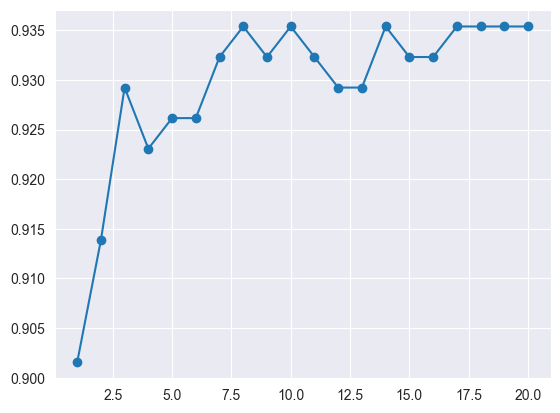

In [188]:
balanced_train_features, balanced_test_features, balanced_train_labels, balanced_test_labels = train_test_split(
    balanced_features, balanced_labels, test_size=0.33, random_state=42, stratify=balanced_labels
)

temp = {d: RandomForestClassifier(n_estimators=500, max_depth=d, random_state=42, n_jobs=-1)
            .fit(balanced_train_features, balanced_train_labels)
            .score(balanced_test_features, balanced_test_labels)
        for d in range(1, 21)}

optimal_depth = max(temp, key=temp.get)
print(f"Meilleure profondeur : {optimal_depth} ({temp[optimal_depth]:.4f})")

plt.plot(temp.keys(), temp.values(), marker='o')
plt.show()

### 12. Résultats et matrice de confusion du meilleur modèle


              precision    recall  f1-score   support

           0       0.89      0.99      0.94       163
           1       0.99      0.88      0.93       162

    accuracy                           0.94       325
   macro avg       0.94      0.94      0.94       325
weighted avg       0.94      0.94      0.94       325



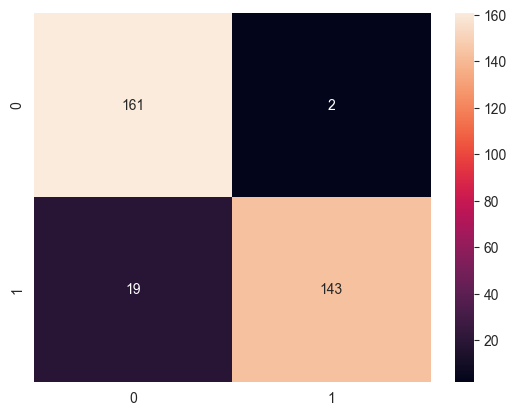

In [189]:
a = RandomForestClassifier(n_estimators=500, max_depth=optimal_depth, random_state=42, n_jobs=-1)
a.fit(balanced_train_features, balanced_train_labels)
b = a.predict(balanced_test_features)

print(classification_report(balanced_test_labels, b))
sns.heatmap(confusion_matrix(balanced_test_labels, b), annot=True, fmt='d')
plt.show()

Sur données équilibrées le modèle détecte vraiment les fraudes, contrairement au jeu déséquilibré où le score était biaisé. La matrice de confusion montre un bon équilibre entre précision et rappel. Les faux négatifs (fraudes ratées) restent les plus coûteux dans ce contexte, c'est ce qu'on cherche à minimiser en priorité.